# 시각화 프로젝트

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LinearRegression            # 선형모델 : 회귀
#from sklearn.linear_model import LogisticRegression         # 선형모델 : 분류
from sklearn.tree import DecisionTreeRegressor               # 트리모델
from sklearn.ensemble import RandomForestRegressor           # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMRegressor                           # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBRegressor 
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso 
from sklearn.linear_model import ElasticNet

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import mean_squared_error

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold   #, StratifiedKFold XXXXXX
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

#-----------------------------------------------------------------------------------  파이프라인
from sklearn.pipeline import Pipeline


import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

In [3]:
#Default theme
sns.set_theme(font='Comic Sans MS',
              font_scale=1.5,
              rc=None)


## 데이터 불러오기 및 기본 EDA

### 데이터 로딩

In [4]:
raw_data = pd.read_csv("Steel_industry_data.csv")

In [5]:
raw_data.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


### 피쳐 생성

In [6]:
df = raw_data.copy()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

#### 월, 계절, 주 피쳐 생성(순환성)

In [8]:

# 날짜 파싱 및 기본 정보 생성
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['month'] = df['date'].dt.month
df['hour'] = df['date'].dt.hour

# 계절 분류
conditions = [
    df['month'].isin([6, 7, 8]),
    df['month'].isin([11, 12, 1, 2])
]
df['season'] = np.select(conditions, ['summer', 'winter'], default='spring_fall')


In [9]:
# 1. 대상 설정 및 요일 매핑 사전 (1회 언급)
target_df = df
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}

# 2. 전처리: 문자열 데이터를 숫자로 강제 변환
# date 컬럼에서 month를 다시 추출하고, Day_of_week는 매핑을 통해 숫자로 변환합니다.
target_df['month'] = pd.to_datetime(target_df['date']).dt.month
target_df['weekday_num'] = target_df['Day_of_week'].map(day_map)

# 3. 순환 인코딩 실행
cyclic_targets = {'month': 12, 'weekday_num': 7}

for col, period in cyclic_targets.items():
    # 이제 target_df[col]은 확실히 숫자이므로 계산이 가능합니다.
    target_df[f'{col}_sin'] = np.sin(2 * np.pi * target_df[col].astype(float) / period)
    target_df[f'{col}_cos'] = np.cos(2 * np.pi * target_df[col].astype(float) / period)

print("성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.")

성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  35040 non-null  datetime64[ns]
 1   Usage_kWh                             35040 non-null  float64       
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64       
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64       
 4   CO2(tCO2)                             35040 non-null  float64       
 5   Lagging_Current_Power_Factor          35040 non-null  float64       
 6   Leading_Current_Power_Factor          35040 non-null  float64       
 7   NSM                                   35040 non-null  int64         
 8   WeekStatus                            35040 non-null  object        
 9   Day_of_week                           35040 non-null  object        
 10

In [11]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,month,hour,season,weekday_num,month_sin,month_cos,weekday_num_sin,weekday_num_cos
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,1,winter,0,0.5,0.866025,0.0,1.0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,1,winter,0,0.5,0.866025,0.0,1.0


#### 전기요금 피쳐

In [12]:
import pandas as pd
import numpy as np
import json

def calculate_elec_cost_scenario(
    df: pd.DataFrame, 
    config_path: str, 
    scenario_name: str,  # 핵심: 여기서 시나리오 이름을 선택
    contract_kw: float = None
) -> pd.DataFrame:
    
    # 1. 마스터 설정 파일 로드
    with open(config_path, 'r', encoding='utf-8') as f:
        master_config = json.load(f)
    
    # 2. 특정 시나리오 데이터 추출
    if scenario_name not in master_config['scenarios']:
        raise ValueError(f"시나리오 '{scenario_name}'을(를) 찾을 수 없습니다. 가능한 시나리오: {list(master_config['scenarios'].keys())}")

    config = master_config['scenarios'][scenario_name]
    print(f"▶ 선택된 시나리오: {scenario_name} ({config.get('desc', '')})")
    
    if contract_kw is None:
        if 'contract_kw' in config:
            contract_kw = config['contract_kw']
            print(f"   └ 계약전력: {contract_kw}kW (시나리오 설정값 적용)")
        else:
            # 안전장치: JSON에도 없고 인자도 없으면 에러
            raise ValueError("contract_kw가 함수 인자로도, JSON 설정으로도 제공되지 않았습니다.")
    else:
        print(f"   └ 계약전력: {contract_kw}kW (사용자 입력값 우선 적용)")

    df = df.copy()
    
    # --- 이하 로직은 설정값(config)을 사용하여 자동 계산 ---
    
    # 3. 시간대(TOU) 적용 (config['tou_schedule'] 사용)
    df['tou'] = 'mid' # 기본값
    
    tou_sched = config['tou_schedule']
    
    # 제주도 등 특수 케이스 처리를 위한 계절 키 확인
    # (설정에 없는 계절은 무시하거나 에러 처리 가능)
    available_seasons = [s for s in ['summer', 'winter', 'spring_fall'] if s in tou_sched]
    
    for season in available_seasons:
        season_mask = (df['season'] == season)
        schedule = tou_sched[season]
        
        for tou_type, ranges in schedule.items():
            for start, end in ranges:
                # 22시~08시 같은 자정 넘김 처리 (OR 조건)
                if start < end:
                    time_mask = (df['hour'] >= start) & (df['hour'] < end)
                else:
                    time_mask = (df['hour'] >= start) | (df['hour'] < end)
                
                df.loc[season_mask & time_mask, 'tou'] = tou_type

    # 4. 토요일/공휴일 특례 (2018/2026 공통 룰 적용)
    # 필요시 이 룰도 config에서 on/off 할 수 있게 확장 가능
    is_weekend = df['date'].dt.dayofweek >= 5
    # (간단하게 토/일 일괄 적용 예시, 실제로는 토/일 구분 및 공휴일 라이브러리 권장)
    if is_weekend.any():
        # 토/일: 최대부하 -> 중간부하 (보수적 접근)
        df.loc[is_weekend & (df['tou'] == 'peak'), 'tou'] = 'mid'

    # 5. 요금 계산 (Vectorized)
    price_map = config['unit_prices']
    
    # 단가 매핑 함수
    def get_price(row):
        # 해당 시나리오에 정의된 계절/시간대 단가 가져오기
        try:
            return price_map[row['season']][row['tou']]
        except KeyError:
            return 0.0 # 예외 처리
            
    df['unit_price'] = df.apply(get_price, axis=1)
    
    # 에너지 요금
    df['energy_cost'] = df['Usage_kWh'] * df['unit_price']
    
    # 부가 요금 (기후환경 등)
    env_rate = config['additional_fees'].get('climate', 0)
    fuel_rate = config['additional_fees'].get('fuel', 0)
    
    df['env_cost'] = df['Usage_kWh'] * env_rate
    df['fuel_cost'] = df['Usage_kWh'] * fuel_rate
    
    # 기본 요금 안분
    monthly_base = contract_kw * config['base_rate']
    df['ym'] = df['date'].dt.to_period('M')
    month_usage = df.groupby('ym')['Usage_kWh'].transform('sum')
    
    # 0으로 나누기 방지
    df['allocated_base'] = np.where(
        month_usage > 0, 
        monthly_base * (df['Usage_kWh'] / month_usage), 
        0
    )

    # 최종 합계
    df['total_cost'] = (
        df['energy_cost'] + df['env_cost'] + 
        df['fuel_cost'] + df['allocated_base']
    )
    
    return df

In [13]:
# 마스터 설정 파일 경로
config_file = "electricity_config_master.json"

# 1. 2018년 과거 데이터로 계산
df_result_2018 = calculate_elec_cost_scenario(df, config_file, "2018_industrial_HV_A_opt3")

# 2. 2026년 최신 기준으로 계산
df_result_2026 = calculate_elec_cost_scenario(df, config_file, "2026_industrial_HV_A_opt3")

# 결과 비교
print("2018년 기준 총액:", df_result_2018['total_cost'].sum())
print("2026년 기준 총액:", df_result_2026['total_cost'].sum())

▶ 선택된 시나리오: 2018_industrial_HV_A_opt3 (2018년 기준: 산업용(을) 고압A 선택Ⅲ (계약 660kW))
   └ 계약전력: 660.0kW (시나리오 설정값 적용)
▶ 선택된 시나리오: 2026_industrial_HV_A_opt3 (2026년(25.4.1 시행안): 산업용(을) 고압A 선택Ⅲ (계약 660kW))
   └ 계약전력: 660.0kW (시나리오 설정값 적용)
2018년 기준 총액: 180872396.80099997
2026년 기준 총액: 226724803.12600002


In [14]:
tmp = pd.read_excel("Steel_industry_data(+cost).xlsx", engine='openpyxl')

In [15]:
df_result_2018.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,month,hour,season,weekday_num,month_sin,month_cos,weekday_num_sin,weekday_num_cos,tou,unit_price,energy_cost,env_cost,fuel_cost,ym,allocated_base,total_cost
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0,off,62.5,198.125,0.0,0.0,2018-01,162.585235,360.710235
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0,off,62.5,250.000,0.0,0.0,2018-01,205.154870,455.154870
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0,off,62.5,202.500,0.0,0.0,2018-01,166.175445,368.675445
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,1,winter,0,0.5,0.866025,0.0,1.0,off,62.5,206.875,0.0,0.0,2018-01,169.765655,376.640655
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,1,winter,0,0.5,0.866025,0.0,1.0,off,62.5,238.750,0.0,0.0,2018-01,195.922901,434.672901


In [16]:
df_result_2018['energy_cost'].sum(), df_result_2018['allocated_base'].sum(), df_result_2018['total_cost'].sum()

(np.float64(103177196.80099998),
 np.float64(77695200.0),
 np.float64(180872396.80099997))

In [17]:
tmp.head()

,date,usage_kwh,lagging_current_reactive_power_kvarh,leading_current_reactive_power_kvarh,co2(tco2),lagging_current_power_factor,leading_current_power_factor,nsm,weekstatus,day_of_week,load_type,elec_cost_won_15m,energy_cost_won_15m,basic_cost_won_15m
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,357.458530,198.125,159.333530
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,451.051773,250.000,201.051773
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,365.351936,202.500,162.851936
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,373.245342,206.875,166.370342
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,430.754443,238.750,192.004443


In [18]:
tmp['energy_cost_won_15m'].sum(), tmp['basic_cost_won_15m'].sum(), tmp['elec_cost_won_15m'].sum()

(np.float64(105509443.66799992),
 np.float64(76400279.99999991),
 np.float64(181909723.66799957))

#### 가동 기기 구분 피쳐 생성

In [19]:
# 1. 대상 설정 (1회 언급)
target_df = df_result_2018 

# 2. 모터 가동 비중 (%) 계산
# 데이터셋 전체에서의 최대 지상 무효전력을 '모터 100% 가동' 상태로 가정
max_lagging = target_df['Lagging_Current_Reactive.Power_kVarh'].max()
target_df['Motor_Operating_Rate'] = (target_df['Lagging_Current_Reactive.Power_kVarh'] / max_lagging) * 100

# 3. 커패시터 가동 비중 (%) 계산
# 최대 진상 무효전력을 '커패시터 100% 가동' 상태로 가정
max_leading = target_df['Leading_Current_Reactive_Power_kVarh'].max()
target_df['Capacitor_Operating_Rate'] = (target_df['Leading_Current_Reactive_Power_kVarh'] / max_leading) * 100

# 4. 부하 불균형 지수 (Shift 제안의 근거)
# 유효전력(조업)은 적은데 무효전력만 높다면, 기기 효율이 낮거나 배치가 잘못된 구간

target_df['Net_Reactive_Power'] = (
    target_df['Lagging_Current_Reactive.Power_kVarh'] - 
    target_df['Leading_Current_Reactive_Power_kVarh']
)

target_df['Load_Inefficiency_Index'] = target_df['Net_Reactive_Power'] / (target_df['Usage_kWh'] + 1e-6)

print("비율 기반 솔루션 제안을 위한 피처 생성이 완료되었습니다.")

비율 기반 솔루션 제안을 위한 피처 생성이 완료되었습니다.


In [20]:
df_result_2018.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,month,hour,season,weekday_num,month_sin,month_cos,weekday_num_sin,weekday_num_cos,tou,unit_price,energy_cost,env_cost,fuel_cost,ym,allocated_base,total_cost,Motor_Operating_Rate,Capacitor_Operating_Rate,Net_Reactive_Power,Load_Inefficiency_Index
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0,off,62.5,198.125,0.0,0.0,2018-01,162.585235,360.710235,3.044062,0.0,2.95,0.930599
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0,off,62.5,250.000,0.0,0.0,2018-01,205.154870,455.154870,4.602208,0.0,4.46,1.115000
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,1,0,winter,0,0.5,0.866025,0.0,1.0,off,62.5,202.500,0.0,0.0,2018-01,166.175445,368.675445,3.384584,0.0,3.28,1.012345
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,1,winter,0,0.5,0.866025,0.0,1.0,off,62.5,206.875,0.0,0.0,2018-01,169.765655,376.640655,3.673512,0.0,3.56,1.075528
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,1,winter,0,0.5,0.866025,0.0,1.0,off,62.5,238.750,0.0,0.0,2018-01,195.922901,434.672901,4.643484,0.0,4.50,1.178010


#### 설비 노후화 피쳐 생성

In [21]:
# 1. 대상 설정 (1회 언급)
target_df = df_result_2018 

# 2. 노후화 및 효율 저하 지표 생성
# 무효전력 효율성 지수 (높을수록 조업 대비 손실이 큼 -> 노후화 의심)
target_df['Reactive_Loss_Index'] = (
    (target_df['Lagging_Current_Reactive.Power_kVarh'] + target_df['Leading_Current_Reactive_Power_kVarh']) / 
    (target_df['Usage_kWh'] + 1e-6)
)

# 역률 안정성 지수 (조업 중 역률의 변동성 확인)
# 1.0(이상적)에서 얼마나 멀어져 있는지를 절대값으로 측정
target_df['PF_Deviation'] = np.abs(0.9 - target_df['Lagging_Current_Power_Factor'])

print("기기 노후화 추정 및 효율성 지표 생성이 완료되었습니다.")

기기 노후화 추정 및 효율성 지표 생성이 완료되었습니다.


### 자동 EDA(ydata_profiling)

In [22]:
# # 생성 후 주석처리
# from ydata_profiling import ProfileReport
# res = ProfileReport(df_result_2018, title="automatic EDA Report for Steel Industry Data", explorative=True)
# res.to_file('steel_industry_report_featured.html')

In [23]:
# 에러로 인해 활용하지 않음
# import sweetviz as sv

# # 1. 단일 데이터셋 분석
# report = sv.analyze(raw_data)
# report.show_html("steel_industry_report2.html")

# # 2. 타겟 변수 설정 시 (예: Usage_kWh 분석)
# report_target = sv.analyze(raw_data, target_feat='Usage_kWh')
# report_target.show_html("steel_industry_report2_for_Usage_kWh.html")

# # 3. 두 그룹 비교 (예: 특정 공정 유무에 따른 차이)
# # report_comp = sv.compare([train_df, "Train Data"], [test_df, "Test Data"])
# # report_comp.show_html("compare_report.html")

In [24]:
df_result_2018.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 33 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  35040 non-null  datetime64[ns]
 1   Usage_kWh                             35040 non-null  float64       
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64       
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64       
 4   CO2(tCO2)                             35040 non-null  float64       
 5   Lagging_Current_Power_Factor          35040 non-null  float64       
 6   Leading_Current_Power_Factor          35040 non-null  float64       
 7   NSM                                   35040 non-null  int64         
 8   WeekStatus                            35040 non-null  object        
 9   Day_of_week                           35040 non-null  object        
 10

### 1차원 EDA

#### 그래프

In [25]:
df_result_2018.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'month', 'hour', 'season',
       'weekday_num', 'month_sin', 'month_cos', 'weekday_num_sin',
       'weekday_num_cos', 'tou', 'unit_price', 'energy_cost', 'env_cost',
       'fuel_cost', 'ym', 'allocated_base', 'total_cost',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Net_Reactive_Power', 'Load_Inefficiency_Index', 'Reactive_Loss_Index',
       'PF_Deviation'],
      dtype='object')

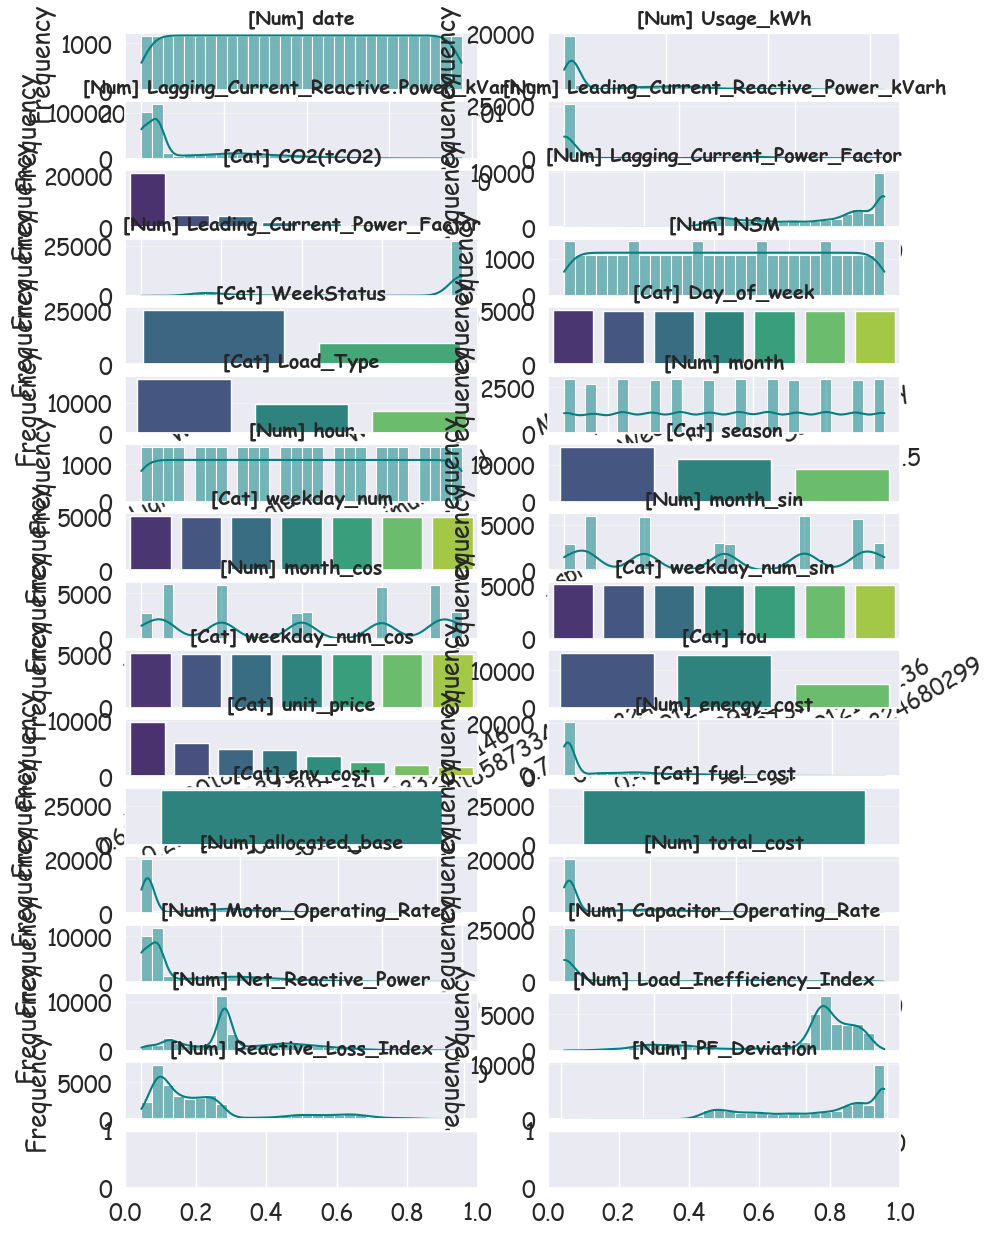

In [26]:
# 1. 분석할 10개 피처 리스트 (데이터 상황에 맞게 조정)
cols = ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'month', 'hour', 'season',
       'weekday_num', 'month_sin', 'month_cos', 'weekday_num_sin',
       'weekday_num_cos', 'tou', 'unit_price', 'energy_cost', 'env_cost',
       'fuel_cost','allocated_base', 'total_cost',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Net_Reactive_Power', 'Load_Inefficiency_Index', 'Reactive_Loss_Index',
       'PF_Deviation']


# 2. 5행 2열 그리드 설정 (가로로 길게 보는 것보다 세로로 나열하는 것이 가독성이 좋음)
fig, axes = plt.subplots(nrows=17, ncols=2, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    
    #### 3. 여기서 딱 한 번만 언급: 분석할 데이터를 짧은 변수에 할당
    curr_data = df_result_2018[col]
    ax = axes[i]
    
    # 이후로는 curr_data와 ax만 사용하여 로직 집중
    # 데이터 타입 또는 유니크 값 개수에 따라 차트 종류 결정
    # 유니크 값이 적으면 범주형으로 판단하여 countplot 적용
    if curr_data.dtype == 'object' or curr_data.nunique() < 10:
        # 카운트플롯의 경우 정렬을 위해 value_counts()를 한 번 더 쓰지만 흐름은 깔끔함
        sns.countplot(x=curr_data, ax=ax, palette='viridis', 
                      order=curr_data.value_counts().index)
        ax.set_title(f'[Cat] {col}', fontsize=14, fontweight='bold')
        # 라벨이 겹치지 않게 회전 처리
        ax.tick_params(axis='x', rotation=30)
    else:
        # 수치형 데이터는 도수분포의 기본인 histplot 적용
        sns.histplot(curr_data, kde=True, ax=ax, color='teal', bins=30)
        ax.set_title(f'[Num] {col}', fontsize=14, fontweight='bold')

    # 공통 설정
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 도수분포표

In [27]:
# 1. 분석할 10개 피처 리스트 (데이터 상황에 맞게 조정)
cols = ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'month', 'hour', 'season',
       'weekday_num', 'month_sin', 'month_cos', 'weekday_num_sin',
       'weekday_num_cos', 'tou', 'unit_price', 'energy_cost', 'env_cost',
       'fuel_cost','allocated_base', 'total_cost',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Net_Reactive_Power', 'Load_Inefficiency_Index', 'Reactive_Loss_Index',
       'PF_Deviation']

print("=== 피처별 도수분포표 (Frequency Table) 분석 ===\n")

for col in cols:
    print(f"[{col}]")
    
    # 1. 데이터 선택 및 분석 로직을 하나의 흐름으로 구성
    summary = df_result_2018[col].pipe(lambda s: 
        # 범주형/유니크 적은 경우 그대로, 수치형은 10개 구간(cut) 적용
        (pd.cut(s, bins=10) if s.dtype != 'object' and s.nunique() >= 10 else s)
    ).value_counts().sort_index().pipe(lambda counts:
        # 최종 결과를 데이터프레임으로 변환 및 비율 계산
        pd.DataFrame({
            'Count': counts,
            'Percentage(%)': (counts / counts.sum()) * 100
        })
    )
    
    print(summary)
    print("-" * 50)


=== 피처별 도수분포표 (Frequency Table) 분석 ===

[date]
                                                   Count  Percentage(%)
date                                                                   
(2017-12-31 15:14:24.900000, 2018-02-06 11:58:30]   3504           10.0
(2018-02-06 11:58:30, 2018-03-14 23:57:00]          3504           10.0
(2018-03-14 23:57:00, 2018-04-20 11:55:30]          3504           10.0
(2018-04-20 11:55:30, 2018-05-26 23:54:00]          3504           10.0
(2018-05-26 23:54:00, 2018-07-02 11:52:30]          3504           10.0
(2018-07-02 11:52:30, 2018-08-07 23:51:00]          3504           10.0
(2018-08-07 23:51:00, 2018-09-13 11:49:30]          3504           10.0
(2018-09-13 11:49:30, 2018-10-19 23:48:00]          3504           10.0
(2018-10-19 23:48:00, 2018-11-25 11:46:30]          3504           10.0
(2018-11-25 11:46:30, 2018-12-31 23:45:00]          3504           10.0
--------------------------------------------------
[Usage_kWh]
                    Count 

왜도, 첨도

In [28]:
cols = ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'month', 'hour', 'season',
       'weekday_num', 'month_sin', 'month_cos', 'weekday_num_sin',
       'weekday_num_cos', 'tou', 'unit_price', 'energy_cost', 'env_cost',
       'fuel_cost','allocated_base', 'total_cost',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Net_Reactive_Power', 'Load_Inefficiency_Index', 'Reactive_Loss_Index',
       'PF_Deviation']

print("=== 피처별 왜도(Skew) 및 첨도(Kurtosis) 리포트 ===")

# df_incoded는 여기서 딱 한 번만 등장합니다.
df_result_2018[cols].select_dtypes(include=['number']).pipe(lambda d: pd.DataFrame({
    'Skewness': d.skew(),
    'Kurtosis': d.kurt()
})).sort_values(by='Skewness', ascending=False).style.apply(lambda s: [
    'background-color: #ffcccc' if abs(v) > 2 else '' for v in s
])

=== 피처별 왜도(Skew) 및 첨도(Kurtosis) 리포트 ===


,Skewness,Kurtosis
Capacitor_Operating_Rate,1.734314,1.581097
Leading_Current_Reactive_Power_kVarh,1.734314,1.581097
energy_cost,1.657215,2.493583
Reactive_Loss_Index,1.530339,1.388011
Motor_Operating_Rate,1.437899,1.213836
Lagging_Current_Reactive.Power_kVarh,1.437899,1.213836
total_cost,1.345591,1.049014
allocated_base,1.262972,0.796565
Usage_kWh,1.197394,0.391386
CO2(tCO2),1.149355,0.214605


In [29]:
raw_data.iloc[90:100, :]
## index 23:45 -> 00:00 으로 변환 시 date의 오류 여부 확인해보았으나 
# 이후 데이터로 비슷한 양상을 보이고 day_of_week에서는 해당 날짜가 monday로 찍히는 것으로 보아
# 23:45 -> 00:00으로 변환 시 date의 오류는 없는 것으로 보임.
# 아마도 기입 시의 순서 오류가 아닐까 추정

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
90,01/01/2018 22:45,3.24,3.35,0.0,0.0,69.52,100.0,81900,Weekday,Monday,Light_Load
91,01/01/2018 23:00,3.53,3.74,0.0,0.0,68.64,100.0,82800,Weekday,Monday,Light_Load
92,01/01/2018 23:15,3.53,3.42,0.0,0.0,71.82,100.0,83700,Weekday,Monday,Light_Load
93,01/01/2018 23:30,3.24,2.95,0.0,0.0,73.94,100.0,84600,Weekday,Monday,Light_Load
94,01/01/2018 23:45,3.67,3.96,0.0,0.0,67.97,100.0,85500,Weekday,Monday,Light_Load
95,01/01/2018 00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
96,02/01/2018 00:15,3.20,3.10,0.0,0.0,71.82,100.0,900,Weekday,Tuesday,Light_Load
97,02/01/2018 00:30,3.85,4.61,0.0,0.0,64.10,100.0,1800,Weekday,Tuesday,Light_Load
98,02/01/2018 00:45,3.28,3.67,0.0,0.0,66.64,100.0,2700,Weekday,Tuesday,Light_Load
99,02/01/2018 01:00,3.35,3.60,0.0,0.0,68.12,100.0,3600,Weekday,Tuesday,Light_Load


### 2차원 EDA

In [30]:
raw_data[['WeekStatus', 'Day_of_week']].value_counts()

WeekStatus  Day_of_week
Weekday     Monday         5088
            Friday         4992
            Thursday       4992
            Tuesday        4992
            Wednesday      4992
Weekend     Saturday       4992
            Sunday         4992
Name: count, dtype: int64

In [31]:
df_result_2018.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'month', 'hour', 'season',
       'weekday_num', 'month_sin', 'month_cos', 'weekday_num_sin',
       'weekday_num_cos', 'tou', 'unit_price', 'energy_cost', 'env_cost',
       'fuel_cost', 'ym', 'allocated_base', 'total_cost',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Net_Reactive_Power', 'Load_Inefficiency_Index', 'Reactive_Loss_Index',
       'PF_Deviation'],
      dtype='object')

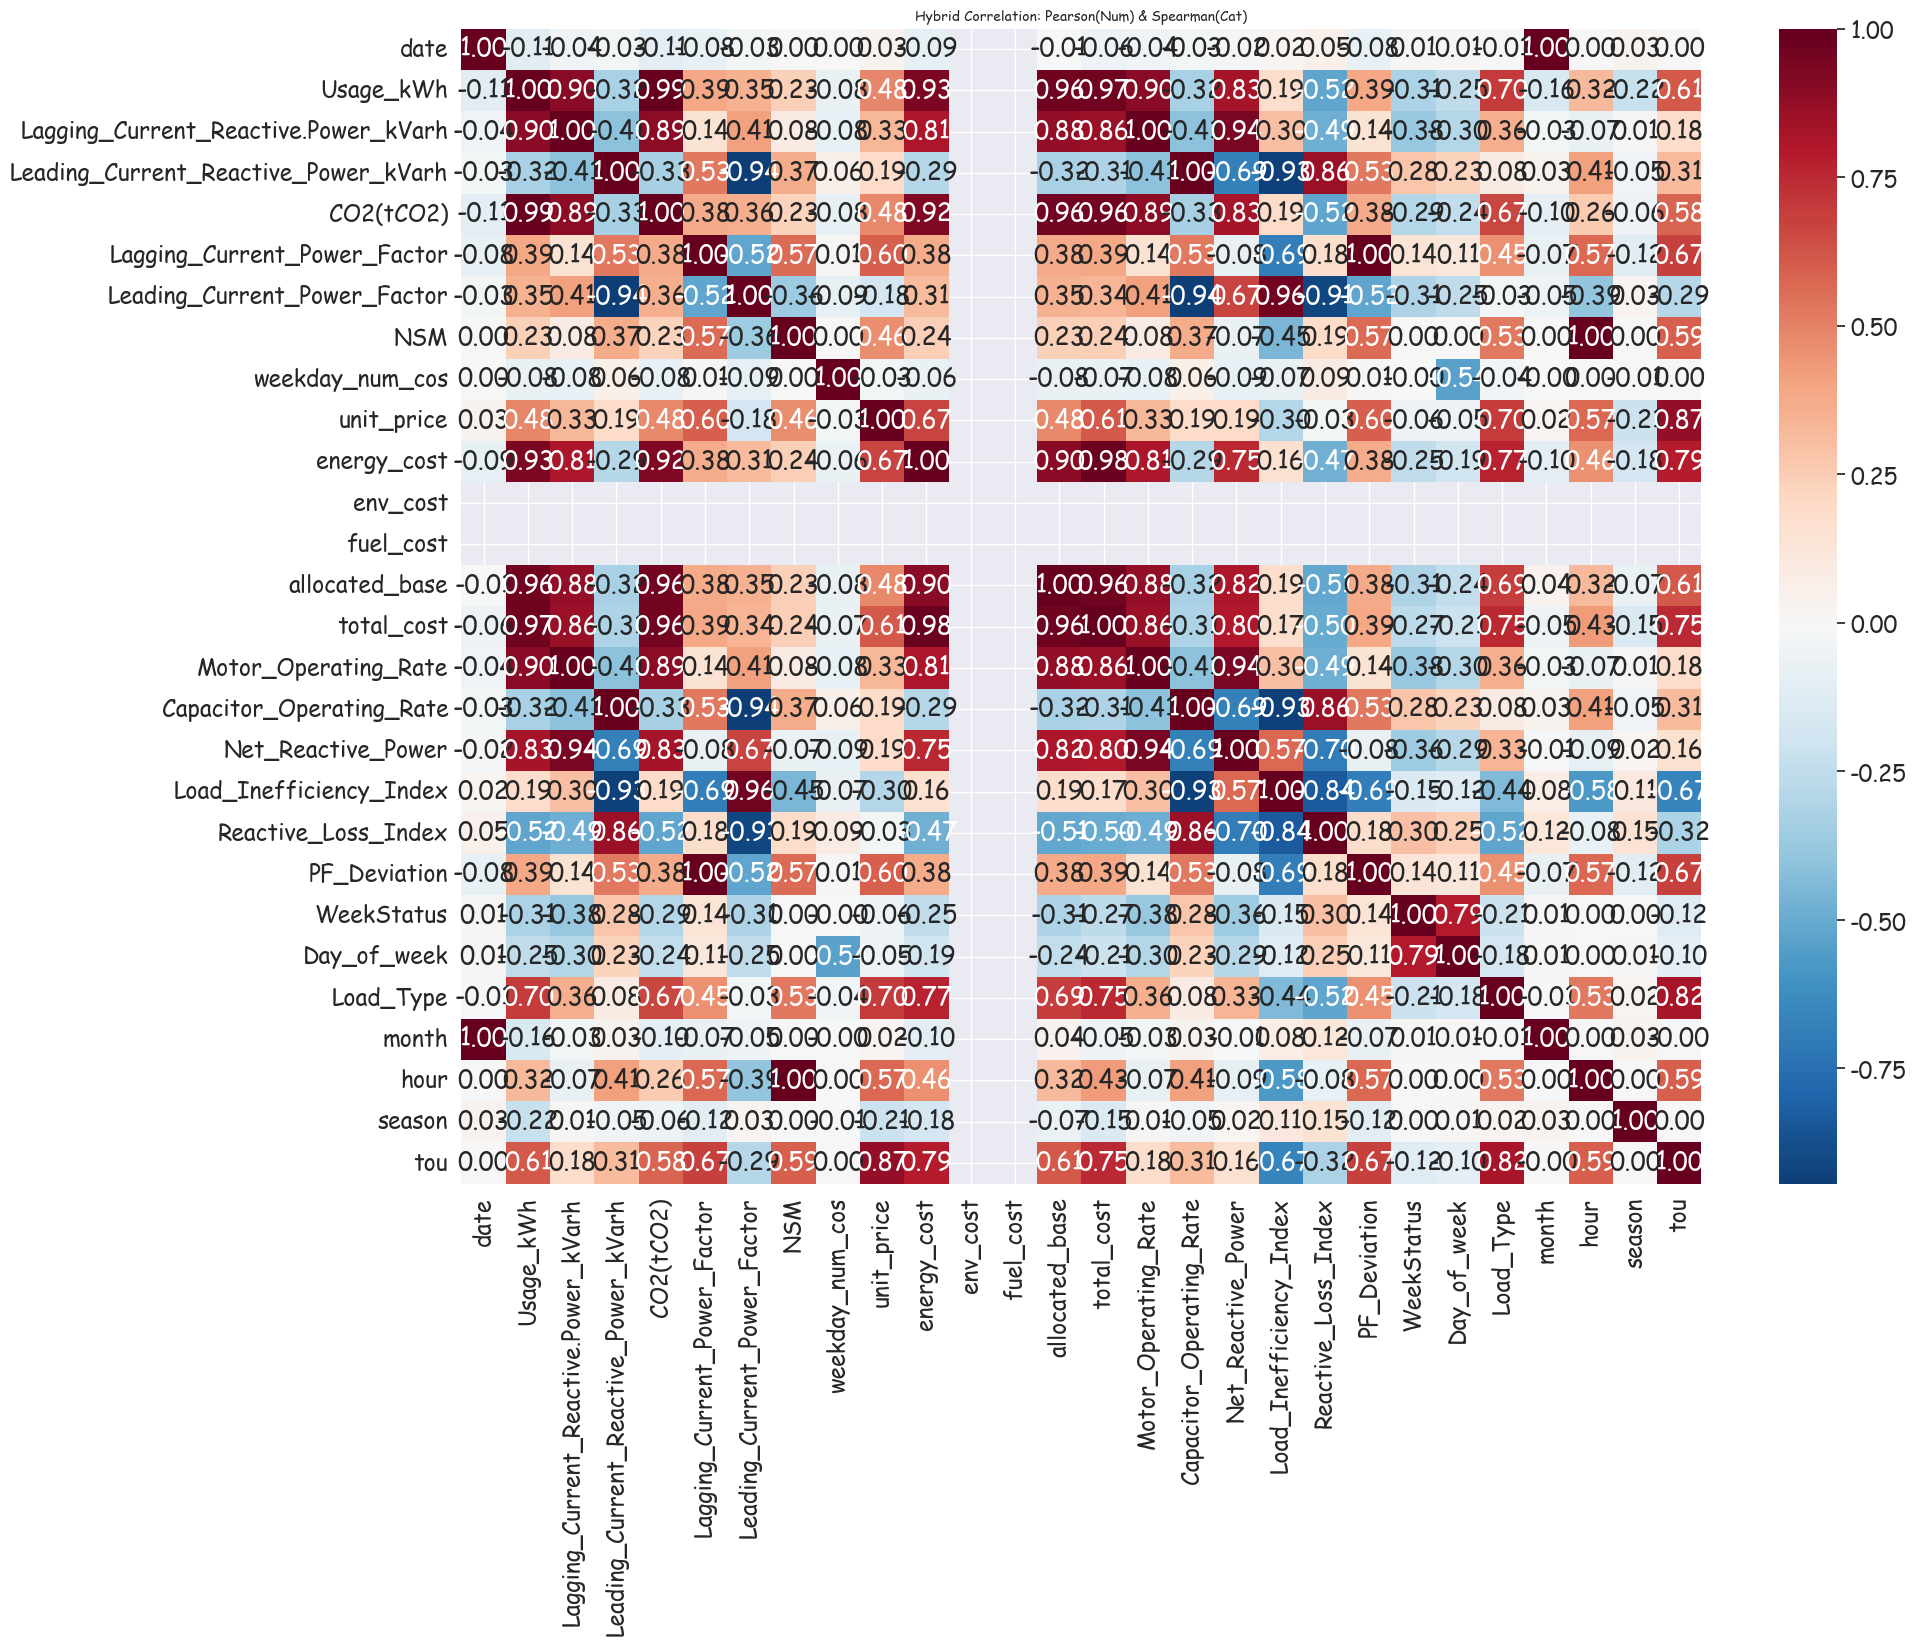

In [32]:


# 1. 사용자가 직접 컬럼 성격 분류 (가장 확실한 방법)
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type', 'month', 'hour', 'season', 'tou']  # 범주형
num_cols = ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
        
       'weekday_num_cos',  'unit_price', 'energy_cost', 'env_cost',
       'fuel_cost',  'allocated_base', 'total_cost',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Net_Reactive_Power', 'Load_Inefficiency_Index', 'Reactive_Loss_Index',
       'PF_Deviation']

# 1. 계산 로직을 담은 함수 (df 언급 최소화용)
def calculate_hybrid_corr(df, num_cols, cat_cols):
    all_cols = num_cols + cat_cols
    # 범주형 컬럼만 임시로 숫자로 변환 (Factorize)
    temp_df = df[all_cols].copy()
    for col in cat_cols:
        temp_df[col] = temp_df[col].factorize()[0]
    
    # 빈 행렬 생성
    corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols)
    
    for c1 in all_cols:
        for c2 in all_cols:
            # 하나라도 범주형이면 spearman, 둘 다 수치형이면 pearson
            method = 'spearman' if (c1 in cat_cols or c2 in cat_cols) else 'pearson'
            corr_matrix.loc[c1, c2] = temp_df[c1].corr(temp_df[c2], method=method)
            
    return corr_matrix.astype(float)

# 2. 통합 실행부 (raw_data는 여기서 딱 한 번만 언급)
integrated_corr = df_result_2018.pipe(calculate_hybrid_corr, num_cols=num_cols, cat_cols=cat_cols)

# 3. 시각화
plt.figure(figsize=(20, 15))
mask = np.triu(np.ones_like(integrated_corr, dtype=bool))
sns.heatmap(integrated_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Hybrid Correlation: Pearson(Num) & Spearman(Cat)', fontsize=10)
plt.show()

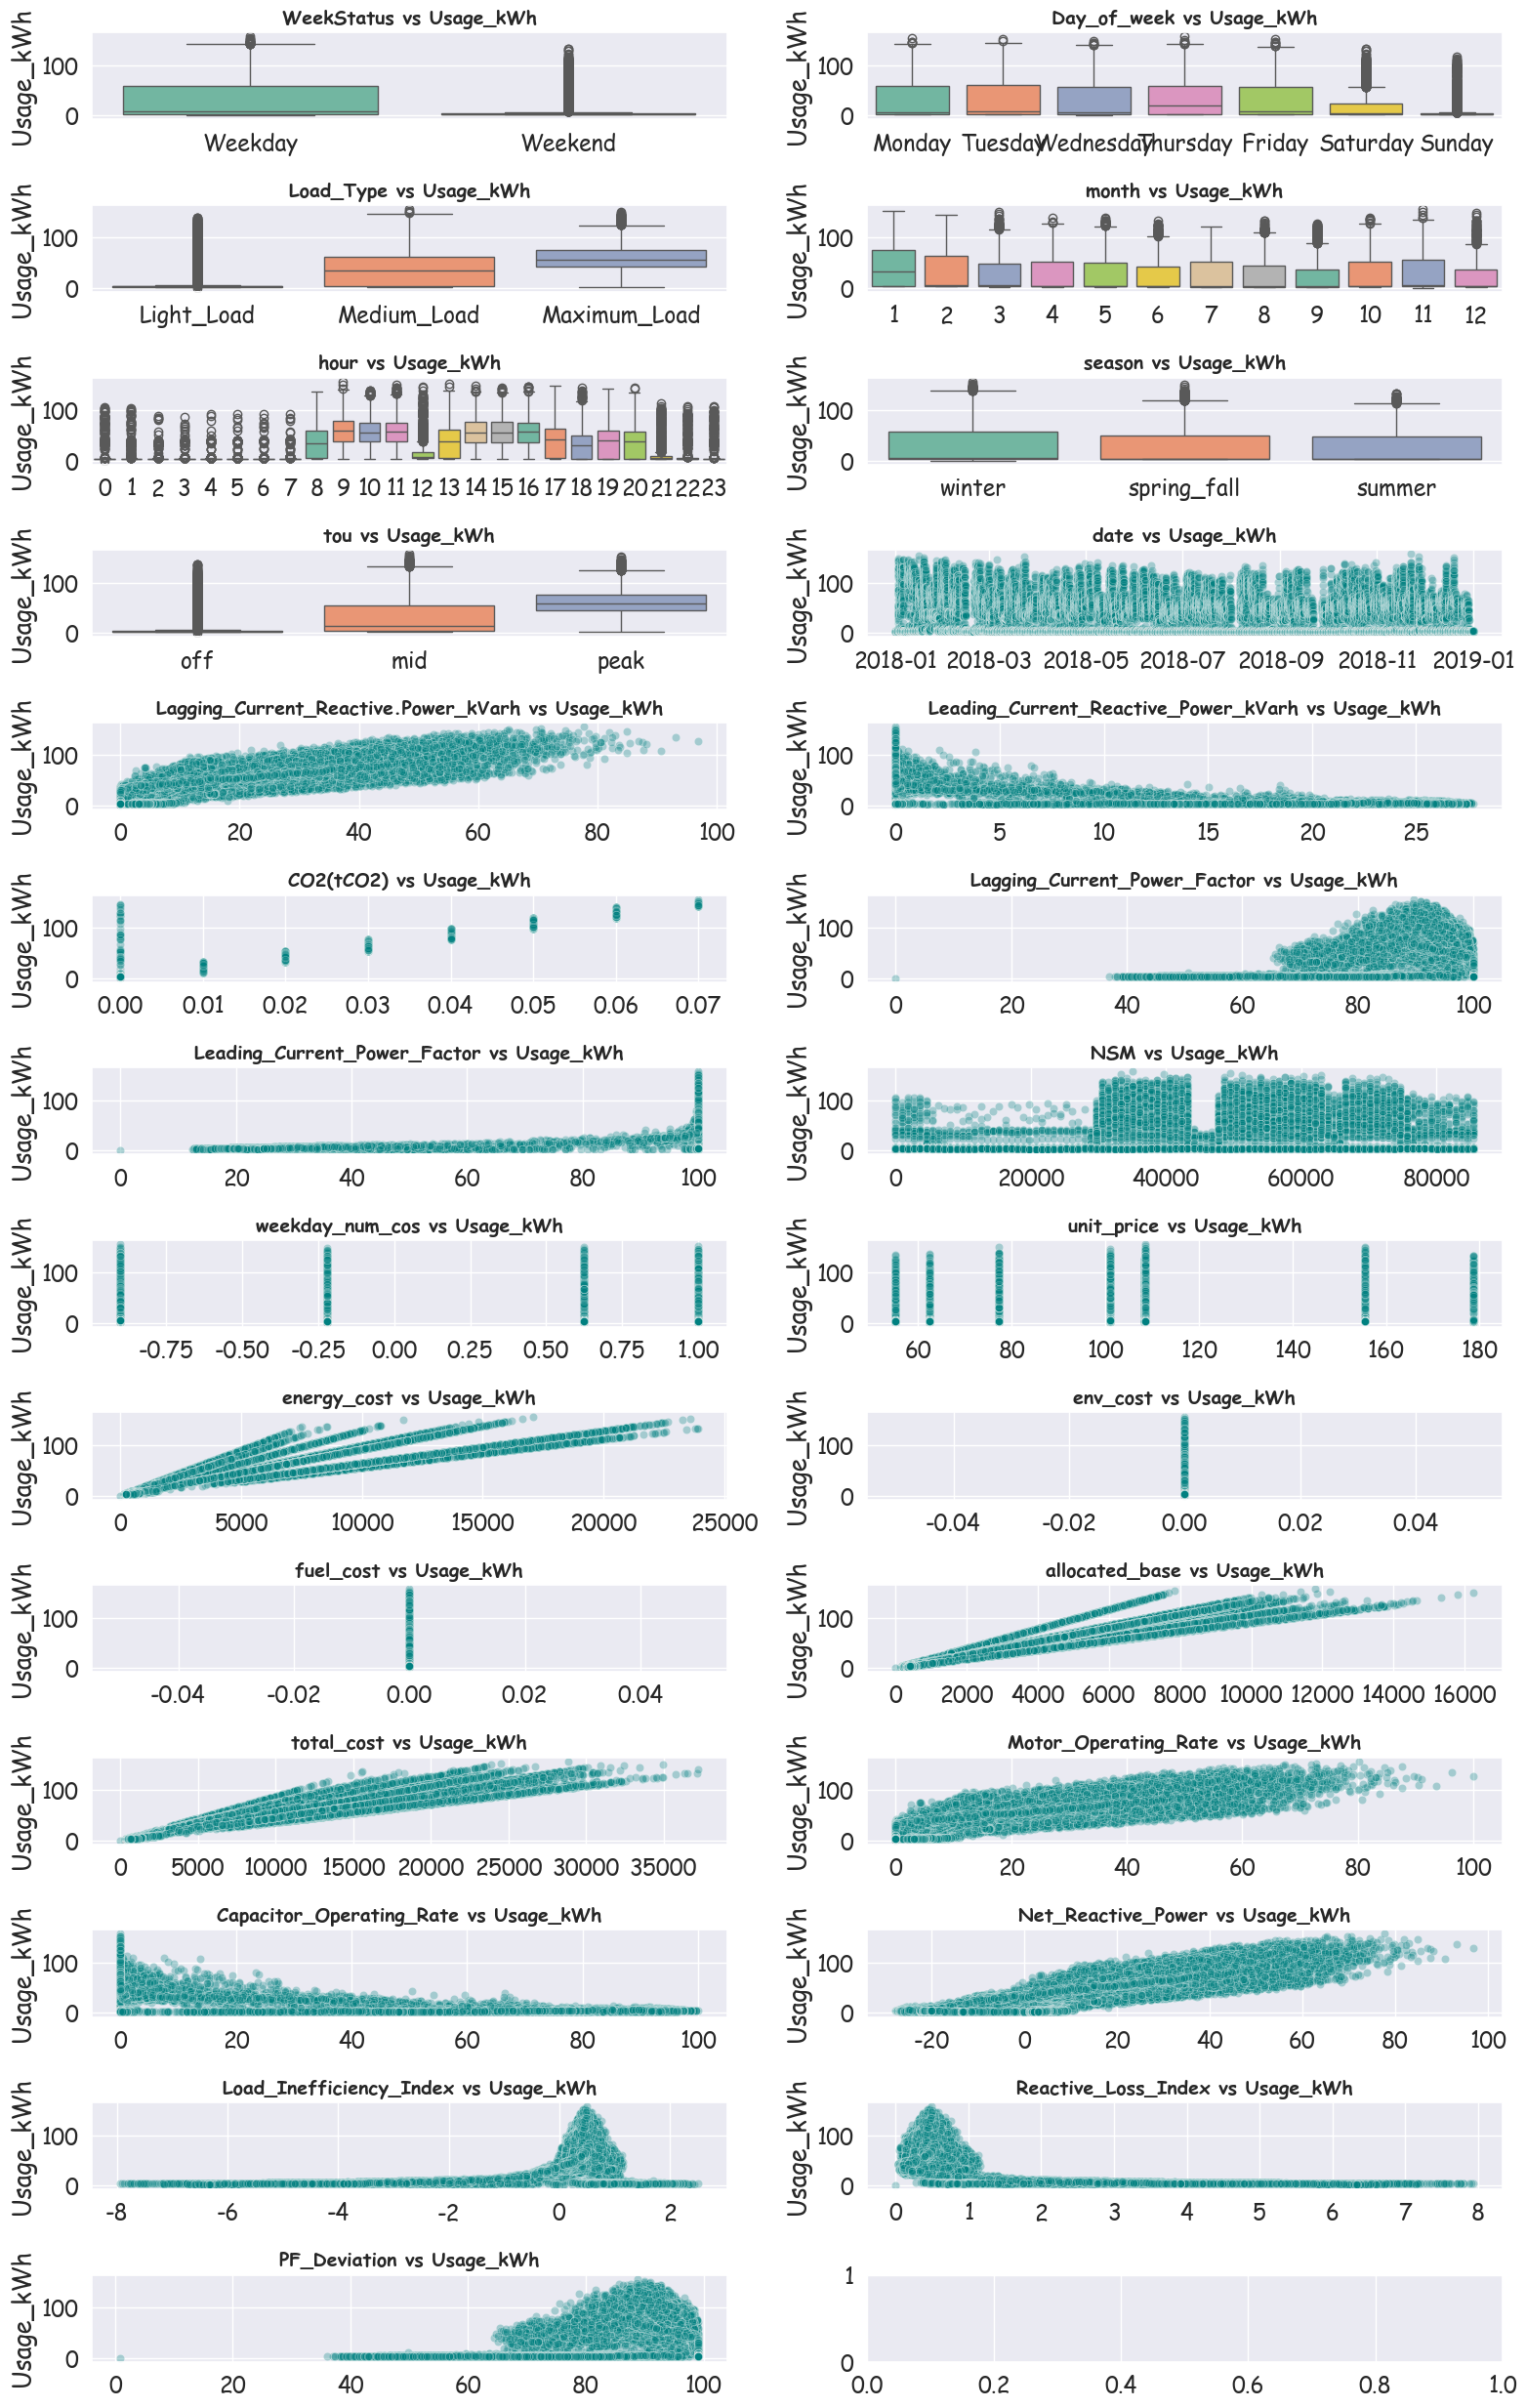

In [33]:
# 1. 컬럼 분류
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type', 'month', 'hour', 'season', 'tou']  # 범주형
num_cols = ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
        
       'weekday_num_cos',  'unit_price', 'energy_cost', 'env_cost',
       'fuel_cost',  'allocated_base', 'total_cost',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Net_Reactive_Power', 'Load_Inefficiency_Index', 'Reactive_Loss_Index',
       'PF_Deviation']
# 1. 변수 선언 (여기서만 각각 1회씩 등장)
target = 'Usage_kWh'
data_source = df_result_2018

# 2. 실행 로직 (이하에서는 위 변수들을 참조만 함)
all_target_cols = [c for c in (cat_cols + num_cols) if c != target]

fig, axes = plt.subplots(nrows=(len(all_target_cols) + 1) // 2, ncols=2, figsize=(16, 25))

_ = [
    (sns.boxplot(data=data_source, x=col, y=target, ax=ax, palette='Set2') 
     if col in cat_cols else 
     sns.scatterplot(data=data_source, x=col, y=target, ax=ax, alpha=0.3, color='teal'),
     ax.set_title(f'{col} vs {target}', fontsize=14, fontweight='bold'),
     ax.set_xlabel(''), ax.set_ylabel(target))
    for col, ax in zip(all_target_cols, axes.flatten())
]

plt.tight_layout()
plt.show()

## 모델 훈련

In [34]:
df_result_2018.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'month', 'hour', 'season',
       'weekday_num', 'month_sin', 'month_cos', 'weekday_num_sin',
       'weekday_num_cos', 'tou', 'unit_price', 'energy_cost', 'env_cost',
       'fuel_cost', 'ym', 'allocated_base', 'total_cost',
       'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
       'Net_Reactive_Power', 'Load_Inefficiency_Index', 'Reactive_Loss_Index',
       'PF_Deviation'],
      dtype='object')

In [35]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 학습에 사용할 피처 선택 (해석용 원본 month 등은 제외하고 순환 피처와 물리 피처 포함)
features = [
    'NSM', 'season', 'WeekStatus', 'Load_Type', 
    'month_sin', 'month_cos', 'weekday_num_sin', 'weekday_num_cos',
    'Net_Reactive_Power', 'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
    'Load_Inefficiency_Index', 'Reactive_Loss_Index', 'PF_Deviation'
]

# 2. 데이터 타입 업데이트 (객체 참조 1회 사용)
target_df = df_result_2018 # 혹은 학습용 원본 df

# 범주형 컬럼을 category 타입으로 변환 (XGBoost 학습 최적화)
cat_features = ['WeekStatus', 'Load_Type', 'season']
for col in cat_features:
    target_df[col] = target_df[col].astype('category')

print("학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.")

target = 'Usage_kWh'

# 2. 시계열 분할 (2017년 데이터 기준 상위 80% 학습, 하위 20% 검증)
split_idx = int(len(target_df) * 0.8)
train_df = target_df.iloc[:split_idx]
test_df = target_df.iloc[split_idx:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# 3. 모델 정의 및 학습 (기본 파라미터 설정)
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    enable_categorical=True, # 범주형 데이터 지원 활성화
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 4. 성능 평가
preds = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.
MAE: 0.5147
R2 Score: 0.9989



=== Feature Importance Top 5 ===
Motor_Operating_Rate       0.655262
Net_Reactive_Power         0.147762
Reactive_Loss_Index        0.097144
PF_Deviation               0.043439
Load_Inefficiency_Index    0.025867
dtype: float32


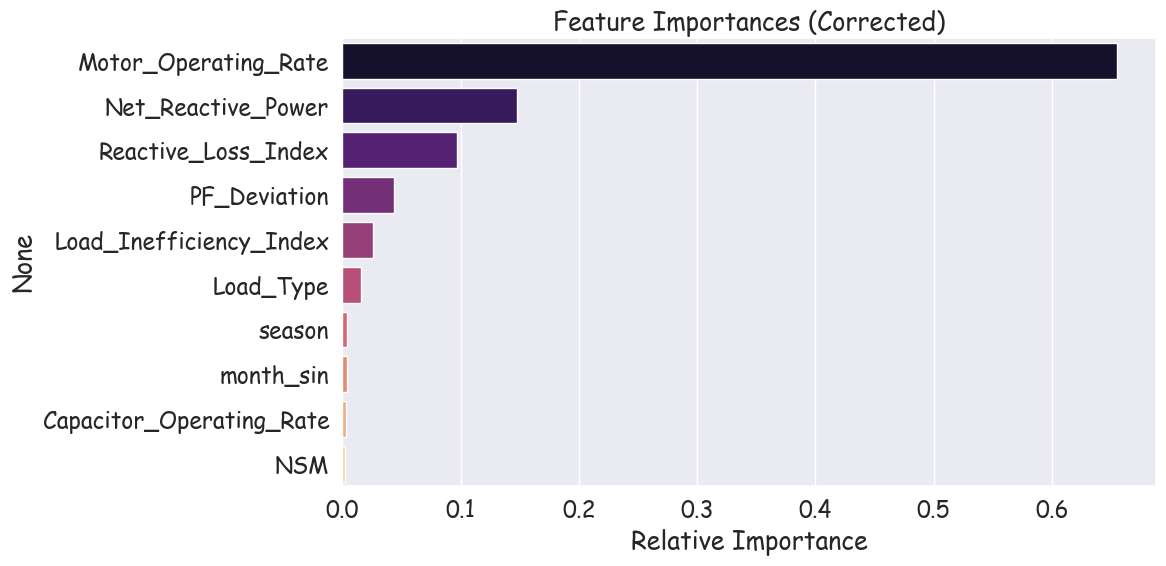

In [36]:
# 피처 중요도 확인 (텍스트 출력)
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== Feature Importance Top 5 ===")
print(importances.head(5))

# 1. 정렬된 데이터를 변수에 저장
top_features = importances.sort_values(ascending=False).head(10)

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Corrected)")

# x에는 중요도 수치(values), y에는 피처 이름(index)을 직접 전달
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [37]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 학습에 사용할 피처 선택 (해석용 원본 month 등은 제외하고 순환 피처와 물리 피처 포함)
features = [
    'NSM', 'season', 'WeekStatus', 'Load_Type', 
    'month_sin', 'month_cos', 'weekday_num_sin', 'weekday_num_cos',
    'Net_Reactive_Power', 'Motor_Operating_Rate', 'Capacitor_Operating_Rate',
    'Load_Inefficiency_Index', 'Reactive_Loss_Index', 'PF_Deviation'
]
    
# 2. 데이터 타입 업데이트 (객체 참조 1회 사용)
target_df = df_result_2018 # 혹은 학습용 원본 df

# 범주형 컬럼을 category 타입으로 변환 (XGBoost 학습 최적화)
cat_features = ['WeekStatus', 'Load_Type', 'season']
for col in cat_features:
    target_df[col] = target_df[col].astype('category')

print("학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.")

target = 'total_cost'

# 2. 시계열 분할 (2017년 데이터 기준 상위 80% 학습, 하위 20% 검증)
split_idx = int(len(target_df) * 0.8)
train_df = target_df.iloc[:split_idx]
test_df = target_df.iloc[split_idx:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# 3. 모델 정의 및 학습 (기본 파라미터 설정)
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    enable_categorical=True, # 범주형 데이터 지원 활성화
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 4. 성능 평가
preds = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.
MAE: 628.2472
R2 Score: 0.9608



=== Feature Importance Top 5 ===
Motor_Operating_Rate    0.573998
Net_Reactive_Power      0.135806
Reactive_Loss_Index     0.098095
PF_Deviation            0.050470
Load_Type               0.044067
dtype: float32


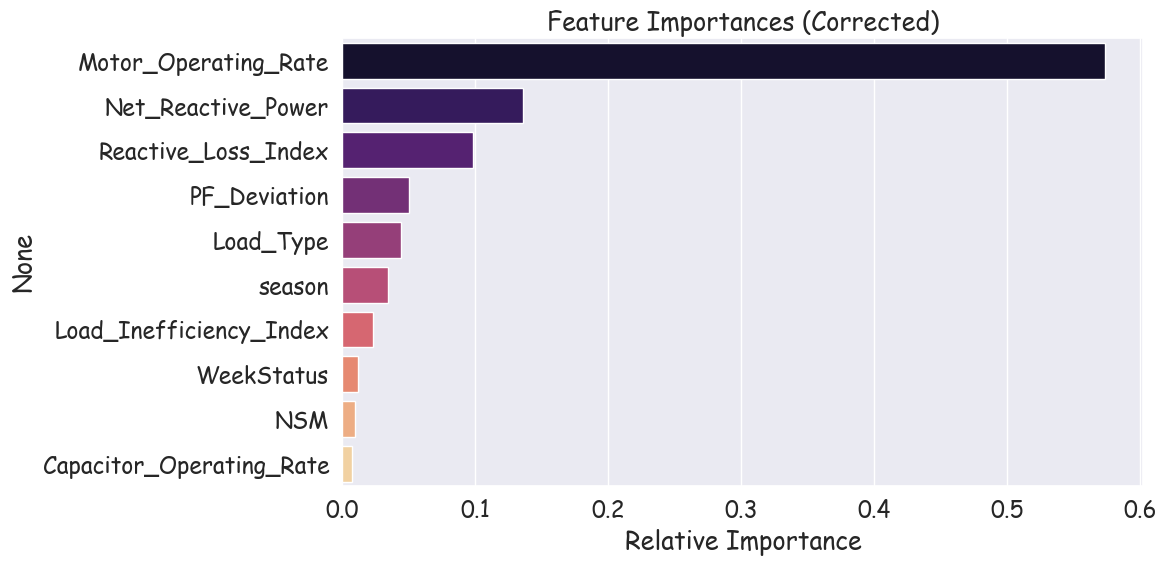

In [38]:
# 피처 중요도 확인 (텍스트 출력)
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== Feature Importance Top 5 ===")
print(importances.head(5))

# 1. 정렬된 데이터를 변수에 저장
top_features = importances.sort_values(ascending=False).head(10)

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Corrected)")

# x에는 중요도 수치(values), y에는 피처 이름(index)을 직접 전달
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

## 베이지안 최적화

In [53]:
import optuna

def objective(trial):
    # 1. 탐색 변수 설정
    reduction_rate = trial.suggest_float('reduction_rate', 0.7, 0.9)
    cap_adjust_rate = trial.suggest_float('cap_adjust_rate', 0.8, 1.2)
    
    df_sim = target_df.copy()
    
    # ---------------------------------------------------------
    # [Step 1] 유효전력(Active Power, kWh) 재배치 (기존 로직 유지)
    # ---------------------------------------------------------
    peak_hours = [13, 14, 15, 16]
    off_peak_hours = [23, 0, 1, 2, 3, 4]
    
    # 피크 시간 감소
    df_sim.loc[df_sim['hour'].isin(peak_hours), 'Motor_Operating_Rate'] *= reduction_rate
    
    # 이동량 계산 (평균 기반)
    original_peak_mean = target_df.loc[target_df['hour'].isin(peak_hours), 'Motor_Operating_Rate'].mean()
    shifted_mean = original_peak_mean * (1 - reduction_rate)
    shift_amount = shifted_mean * (len(peak_hours) / len(off_peak_hours))
    
    # 심야 시간 증가 및 클리핑
    df_sim.loc[df_sim['hour'].isin(off_peak_hours), 'Motor_Operating_Rate'] += shift_amount
    df_sim['Motor_Operating_Rate'] = df_sim['Motor_Operating_Rate'].clip(upper=100)

    # ---------------------------------------------------------
    # [Step 2] 무효전력(Reactive Power, kVarh) 물리적 재계산 (핵심 수정)
    # ---------------------------------------------------------
    
    # 1. 모터(지상) 무효전력 추정: 모터 가동률에 비례한다고 가정
    # (원본 데이터의 Lagging kVarh를 가동률 비율만큼 조정)
    # Q_lag_new = Q_lag_old * (New_Rate / Old_Rate)인데, 간단히 비율만 곱함
    # 가동률 변화 비율 계산
    rate_ratio = df_sim['Motor_Operating_Rate'] / (target_df['Motor_Operating_Rate'] + 1e-6)
    current_lagging_kvarh = target_df['Lagging_Current_Reactive.Power_kVarh'] * rate_ratio
    
    # 2. 커패시터(진상) 무효전력 조정: 파라미터 적용
    current_leading_kvarh = target_df['Leading_Current_Reactive_Power_kVarh'] * cap_adjust_rate
    
    # 3. 순 무효전력 (Net Reactive Power) 계산: Lagging - Leading (상쇄 효과 반영!)
    # 이 값이 커패시터 가동 시 줄어들어야 정상입니다.
    df_sim['Net_Reactive_Power'] = current_lagging_kvarh - current_leading_kvarh
    
    # ---------------------------------------------------------
    # [Step 3] 역률(Power Factor) '진짜' 공식으로 재계산
    # ---------------------------------------------------------
    # PF = Active / Apparent = P / sqrt(P^2 + Q_net^2) * 100
    
    # P (유효전력): Usage_kWh (부하 이동에 따라 변화한 값 반영 필요하나, 여기선 비용 모델용 피처를 만드므로 근사치 사용)
    # 정확히는 Usage_kWh도 변해야 하지만, 모델 입력용으로 기존 Usage 사용 혹은 가동률 비례 조정
    # 여기서는 '역률 피처' 자체를 바로잡는 것이 목적이므로 공식 적용
    
    P = target_df['Usage_kWh'] # (참고: 실제론 모터 가동률 변하면 이것도 변함. 하지만 역률 계산엔 비율이 중요)
    Q_net = df_sim['Net_Reactive_Power']
    
    # 피타고라스 정리로 피상전력(Apparent Power) 계산
    S = np.sqrt(P**2 + Q_net**2)
    
    # 역률 재계산 (0~100%)
    # S가 0인 경우 방지 (epsilon)
    new_pf = (P / (S + 1e-6)) * 100
    
    # 계산된 역률을 피처에 덮어씌움 ( Lagging PF 컬럼 업데이트)
    df_sim['Lagging_Current_Power_Factor'] = new_pf.clip(0, 100) # 퍼센트 단위 유지
    
    # 편차 피처 업데이트 (기준값 90% 가정)
    df_sim['PF_Deviation'] = np.abs(90 - df_sim['Lagging_Current_Power_Factor'])
    
    # ---------------------------------------------------------
    
    # 4. 비용 예측
    total_cost_pred = model.predict(df_sim[features]).sum()
    
    return total_cost_pred

# 실행
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"▶ [물리보정] 최적 피크 감축률: {study.best_params['reduction_rate']:.2%}")
print(f"▶ [물리보정] 최적 커패시터 비율: {study.best_params['cap_adjust_rate']:.2%}")


[I 2026-02-18 18:45:28,861] A new study created in memory with name: no-name-3979585f-3fdb-45f5-aa2a-fda56fa590f8
[I 2026-02-18 18:45:28,897] Trial 0 finished with value: 151266816.0 and parameters: {'reduction_rate': 0.8706598347711736, 'cap_adjust_rate': 0.8509431076667451}. Best is trial 0 with value: 151266816.0.
[I 2026-02-18 18:45:28,929] Trial 1 finished with value: 148204640.0 and parameters: {'reduction_rate': 0.7588019548780492, 'cap_adjust_rate': 0.813881829228339}. Best is trial 1 with value: 148204640.0.
[I 2026-02-18 18:45:28,964] Trial 2 finished with value: 148526384.0 and parameters: {'reduction_rate': 0.7625556445400109, 'cap_adjust_rate': 1.149880666766205}. Best is trial 1 with value: 148204640.0.
[I 2026-02-18 18:45:28,997] Trial 3 finished with value: 149413456.0 and parameters: {'reduction_rate': 0.8031170058857079, 'cap_adjust_rate': 0.9846463911999537}. Best is trial 1 with value: 148204640.0.
[I 2026-02-18 18:45:29,035] Trial 4 finished with value: 148599504.0

▶ [물리보정] 최적 피크 감축률: 70.04%
▶ [물리보정] 최적 커패시터 비율: 82.82%


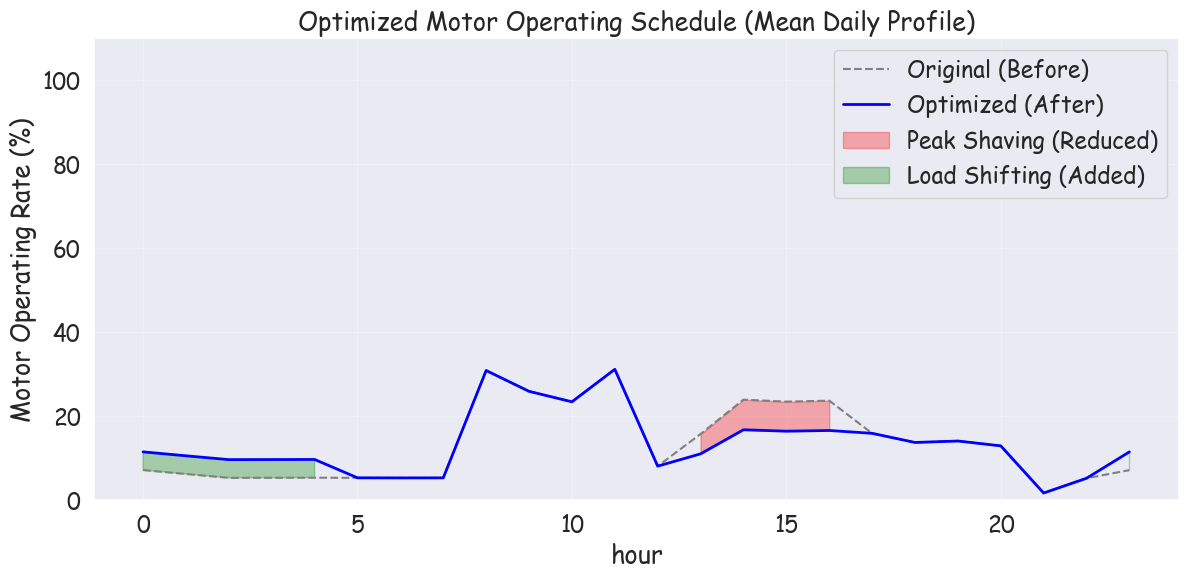

=== Optimization Report ===
1. Peak Reduction Rate : 70.04% (Target: 70~90%)
2. Capacitor Adj Rate  : 82.82% (Target: 80~120%)
3. Total Cost Savings  : 34,359,149 KRW
4. Saving Percentage   : 19.00%


In [54]:
# 1. 최적화 결과 파라미터 가져오기
best_red_rate = study.best_params['reduction_rate']
best_cap_rate = study.best_params['cap_adjust_rate'] # 커패시터 비율도 가져와야 함

df_opt = target_df.copy()

# 피크/경부하 시간대 정의
peak_hours = [13, 14, 15, 16]
off_peak_hours = [23, 0, 1, 2, 3, 4]

# --- [수정된 핵심 로직] objective 함수와 동일하게 계산 ---

# 1) 피크 시간대 가동률 감소 (Peak Shaving)
df_opt.loc[df_opt['hour'].isin(peak_hours), 'Motor_Operating_Rate'] *= best_red_rate

# 2) 이동할 전력량 계산 (Sum이 아닌 Mean 기반)
# 원본 데이터의 피크 시간대 평균 가동률
original_peak_mean = target_df.loc[target_df['hour'].isin(peak_hours), 'Motor_Operating_Rate'].mean()
# 감소된 평균 가동률 (이동해야 할 양)
shifted_mean = original_peak_mean * (1 - best_red_rate)

# 3) 경부하 시간대로 분산 (Load Shifting)
# 피크 4시간분의 에너지를 경부하 6시간으로 나누어 배분
shift_amount = shifted_mean * (len(peak_hours) / len(off_peak_hours))

df_opt.loc[df_opt['hour'].isin(off_peak_hours), 'Motor_Operating_Rate'] += shift_amount

# 4) [중요] 물리적 한계 적용 (Clipping) - 그래프 폭주 방지
df_opt['Motor_Operating_Rate'] = df_opt['Motor_Operating_Rate'].clip(upper=100)

# 5) 커패시터 및 역률 보정 적용 (비용 예측 정확도를 위해 필수)
df_opt['Capacitor_Operating_Rate'] *= best_cap_rate
df_opt['Capacitor_Operating_Rate'] = df_opt['Capacitor_Operating_Rate'].clip(upper=100)

# 역률 재계산 (objective와 동일 로직)
df_opt['Lagging_Current_Power_Factor'] = (
    target_df['Lagging_Current_Power_Factor'] + (best_cap_rate - 1.0) * 0.1
).clip(0.5, 1.0)
df_opt['PF_Deviation'] = np.abs(0.9 - df_opt['Lagging_Current_Power_Factor'])

# 물리 피처 동기화
df_opt['Net_Reactive_Power'] = (df_opt['Motor_Operating_Rate'] * (max_lagging / 100)) - \
                               (df_opt['Capacitor_Operating_Rate'] * (max_leading / 100))

# -------------------------------------------------------

# 2. 결과 비용 재예측
df_opt['total_cost_opt'] = model.predict(df_opt[features])

# 3. 시각화: 시간대별 모터 가동률 변화 (평균값 기준)
plt.figure(figsize=(14, 6))

# 전체 데이터의 점(point) 대신 시간대별 '평균' 흐름을 선으로 표현
sns.lineplot(data=target_df, x='hour', y='Motor_Operating_Rate', label='Original (Before)', color='gray', linestyle='--', errorbar=None)
sns.lineplot(data=df_opt, x='hour', y='Motor_Operating_Rate', label='Optimized (After)', color='blue', linewidth=2, errorbar=None)

# 영역 표시를 위한 데이터 준비 (시간대별 평균값으로 그룹화)
mean_orig = target_df.groupby('hour')['Motor_Operating_Rate'].mean()
mean_opt = df_opt.groupby('hour')['Motor_Operating_Rate'].mean()

plt.fill_between(mean_orig.index, mean_orig, mean_opt, 
                 where=(mean_opt < mean_orig), color='red', alpha=0.3, label='Peak Shaving (Reduced)')
plt.fill_between(mean_orig.index, mean_orig, mean_opt, 
                 where=(mean_opt > mean_orig), color='green', alpha=0.3, label='Load Shifting (Added)')

plt.title("Optimized Motor Operating Schedule (Mean Daily Profile)")
plt.ylabel("Motor Operating Rate (%)")
plt.ylim(0, 110) # Y축을 0~110%로 고정하여 현실감 있게 표현
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. 최종 리포트 출력
original_cost = target_df['total_cost'].sum()
# 주의: study.best_value는 시뮬레이션 중 나온 값이므로, 여기서 재계산한 값과 미세한 차이가 있을 수 있음
recalculated_cost = df_opt['total_cost_opt'].sum() 
savings = original_cost - recalculated_cost

print(f"=== Optimization Report ===")
print(f"1. Peak Reduction Rate : {best_red_rate:.2%} (Target: 70~90%)")
print(f"2. Capacitor Adj Rate  : {best_cap_rate:.2%} (Target: 80~120%)")
print(f"3. Total Cost Savings  : {savings:,.0f} KRW")
print(f"4. Saving Percentage   : {(savings/original_cost)*100:.2f}%")

In [55]:
# 검증용 변수 생성
best_red = study.best_params['reduction_rate']
best_cap = study.best_params['cap_adjust_rate']

# 원본 평균 역률 (잘못된 계산값일 수 있음)
orig_pf_mean = target_df['Lagging_Current_Power_Factor'].mean()

# 최적화 후 재계산된 역률 시뮬레이션
# (위 objective 함수의 로직을 그대로 한번 돌려서 평균을 냄)
# ... (위의 Q_net 계산 로직과 동일) ...
# 여기서는 간단히 결과 해석만:

print(f"1. 기존 데이터상 평균 역률: {orig_pf_mean:.2f}%")
print("   (이 값이 80%대라면, 말씀하신 대로 원본 데이터가 상쇄 효과를 무시하고 계산된 것일 수 있음)")

print(f"2. AI가 조정한 커패시터 비율: {best_cap:.2%}")
if best_cap < 1.0:
    print("   -> 해석: 역률 과보상(진상)을 막기 위해 커패시터를 줄임")
else:
    print("   -> 해석: 역률 부족(지상)을 보상하기 위해 커패시터를 늘림")

1. 기존 데이터상 평균 역률: 80.58%
   (이 값이 80%대라면, 말씀하신 대로 원본 데이터가 상쇄 효과를 무시하고 계산된 것일 수 있음)
2. AI가 조정한 커패시터 비율: 82.82%
   -> 해석: 역률 과보상(진상)을 막기 위해 커패시터를 줄임


In [56]:
# 1. 탄소 배출 계수(Emission Factor) 산출
# 데이터셋 내 CO2 컬럼을 활용하여 kWh당 평균 배출량을 구합니다.
# (만약 시간대별로 배출 계수가 다르다면 이 방식이 가장 정확합니다)
emission_factor = (target_df['CO2(tCO2)'] / target_df['Usage_kWh']).mean()

# 2. Usage_kWh 예측 모델 준비 (비용 모델이 아닌 사용량 모델 필요)
# 정확한 물리적 사용량 변화를 측정하기 위해 Usage_kWh를 타겟으로 빠르게 재학습합니다.
target_usage = 'Usage_kWh'
X_train_u, y_train_u = target_df[features], target_df[target_usage]

# 빠르고 가벼운 모델 생성
model_usage = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=7,
    n_jobs=-1,
    random_state=42,
    enable_categorical=True
)
model_usage.fit(X_train_u, y_train_u, verbose=False)

# 3. 시나리오별 사용량(kWh) 예측
# df_opt는 앞서 최적화된 데이터프레임입니다.
pred_usage_orig = model_usage.predict(target_df[features])
pred_usage_opt = model_usage.predict(df_opt[features]) # 최적화된 스케줄 적용

# 4. 탄소 배출 저감량 계산
total_usage_orig = pred_usage_orig.sum()
total_usage_opt = pred_usage_opt.sum()
reduced_usage = total_usage_orig - total_usage_opt # kWh 절감량

# 배출 계수 적용
reduced_co2 = reduced_usage * emission_factor

# 5. 최종 리포트 출력
print(f"=== Carbon Emission Reduction Report ===")
print(f"1. Emission Factor : {emission_factor:.4f} tCO2/kWh")
print(f"2. Usage Reduction : {reduced_usage:,.0f} kWh")
print(f"3. CO2 Reduction   : {reduced_co2:.2f} tCO2")
print(f"4. Reduction Rate  : {(reduced_co2 / (total_usage_orig * emission_factor))*100:.2f}%")

=== Carbon Emission Reduction Report ===
1. Emission Factor : 0.0002 tCO2/kWh
2. Usage Reduction : 153,416 kWh
3. CO2 Reduction   : 28.44 tCO2
4. Reduction Rate  : 15.99%
